In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import io
from datetime import datetime
import torch
import numpy as np
from model import *
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


In [3]:
device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "xpu"
        if torch.xpu.is_available()
        else "cpu"
    )
print(f"Using {device} device")

Using cpu device


In [4]:
DIRECTORY = "ball_dataset"

### Récupération des 3 ratios les plus probables ###

Traitement des labels:   0%|          | 0/126 [00:00<?, ?it/s]

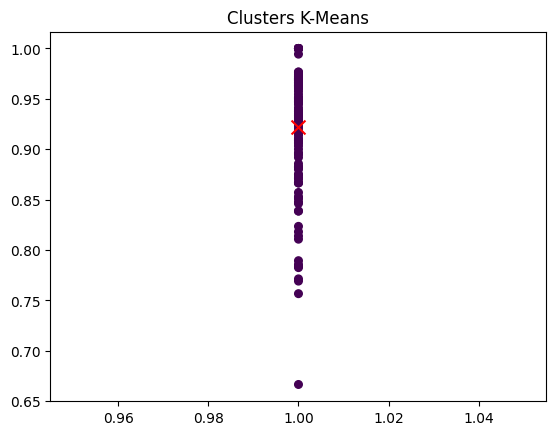

In [5]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from YOLO_loader import get_labels
import time

N_ANCHORS = 1

labels = get_labels(DIRECTORY)
ratios = []
for label in tqdm(labels, desc="Traitement des labels", leave=True):
    boxes = label.get_bounding_boxes()
    for box in boxes :
        box_ratios = box.get_ratio()
        ratios.append(box_ratios)  
    time.sleep(0)
    
ratios = np.array(ratios)
k = N_ANCHORS
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(ratios)  

labels = kmeans.labels_
centers = kmeans.cluster_centers_


plt.scatter(ratios[:, 0], ratios[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100)
plt.title("Clusters K-Means")
plt.show()

### CREATE TRAIN_SETTINGS ###

In [6]:
from train_utils import TrainSettings
from YOLO_loader import get_classes

N_CLASS = len(get_classes(DIRECTORY))
NUM_EPOCHS = 20
BATCH_SIZE = 4
SEED = 42


torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

models = [
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=1,base_kernel_num=16,divider =1),
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=2,base_kernel_num=16,divider =1),
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=3,base_kernel_num=16,divider =1),
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=4,base_kernel_num=16,divider =1)
]



optimizers = [
    torch.optim.Adam(models[i].parameters(), lr=0.001)
    for i in range(4)
]

schedulers = [
    torch.optim.lr_scheduler.ReduceLROnPlateau(optimizers[i], 'min')
    for i in range(4)
]

loss_fns = [YoloLoss(lambda_coord=5,lambda_noobj=0.1,lambda_obj=10),
            YoloLoss(lambda_coord=5,lambda_noobj=0.1,lambda_obj=10),
            YoloLoss(lambda_coord=5,lambda_noobj=0.1,lambda_obj=10),
            YoloLoss(lambda_coord=5,lambda_noobj=0.1,lambda_obj=10)]


TrainSettingsArray = [
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,schedulers[0],optimizers[0],loss_fns[0]),
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,schedulers[1],optimizers[1],loss_fns[1]),
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,schedulers[2],optimizers[2],loss_fns[2]),
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,schedulers[3],optimizers[3],loss_fns[3])
]

### CREATE DATASET ###


In [7]:
from dataset import CardRecognitionDataset

def getDataLoaders(index):
    reduction_factor = models[index].get_reduction_factor()

    dataset = CardRecognitionDataset(directory= DIRECTORY,is_dark_and_white=False,reduction_factor=reduction_factor,bounding_boxes_ratio=centers)
    STD = dataset.get_std()
    MEAN = dataset.get_mean()

    from dataset import custom_collate_fn, CustomBatchSampler
    from torch.utils.data import Subset,DataLoader
    import random

    N = dataset.__len__()
    train_size = int(0.7 * N)
    val_size   = int(0.2 * N)   
    indices = torch.randperm(N)
    test_size  = N - train_size - val_size

    full_groups = dataset.get_image_size_groups()

    train_groups = {}
    val_groups = {}
    test_groups = {}

    # 2. Diviser CHAQUE groupe en Train/Val/Test pour préserver l'équilibre des tailles
    for size, indices in full_groups.items():
        # Mélanger les indices de ce groupe spécifique
        random.shuffle(indices)
        
        n_total = len(indices)
        n_train = int(0.7 * n_total)
        n_val   = int(0.2 * n_total)
        
        train_groups[size] = indices[:n_train]
        val_groups[size]   = indices[n_train:n_train+n_val]
        test_groups[size]  = indices[n_train+n_val:]

    # 3. Créer les Samplers avec ces groupes filtrés
    train_sampler = CustomBatchSampler(dataset, training_settings.batch_size, groups=train_groups)
    val_sampler   = CustomBatchSampler(dataset, training_settings.batch_size, groups=val_groups)
    test_sampler  = CustomBatchSampler(dataset, training_settings.batch_size, groups=test_groups)

    # 4. Créer les DataLoaders
    train_loader = DataLoader(dataset, batch_sampler=train_sampler, collate_fn=custom_collate_fn, num_workers=1)
    val_loader   = DataLoader(dataset, batch_sampler=val_sampler,   collate_fn=custom_collate_fn, num_workers=1)
    test_loader  = DataLoader(dataset, batch_sampler=test_sampler,  collate_fn=custom_collate_fn, num_workers=1)

    
    return train_loader,val_loader,test_loader

### CREATE DATA LOADER ###

### TRAINING ###

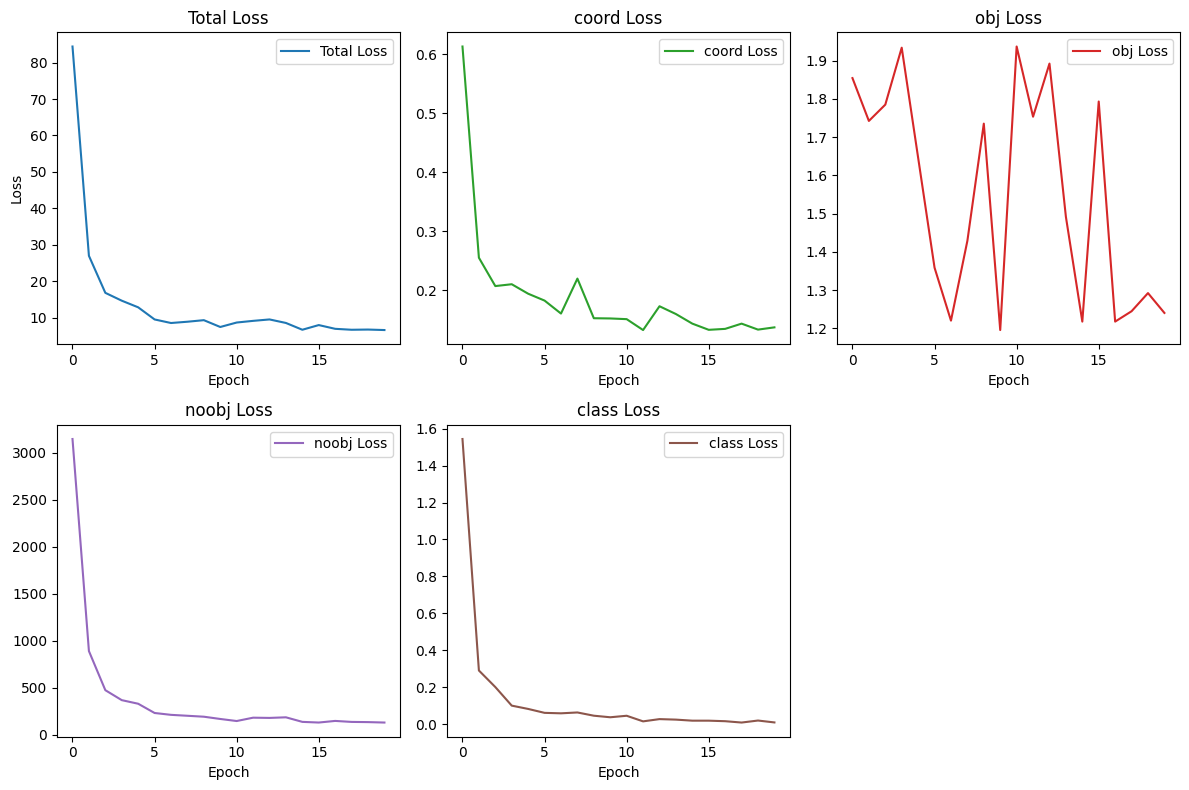

In [8]:
from train_utils import run_one_epoch, get_plot_loss

for i in range(len(TrainSettingsArray)):
    model = models[i]
    training_settings = TrainSettingsArray[i]
    epochs_loss = []

    reduction_factor = training_settings.reduction_factor
    train_loader,val_loader,test_loader = getDataLoaders(i)
    for epoch in range(training_settings.num_epochs):
        loss = run_one_epoch(train_loader,model,training_settings.loss_fn,training_settings.optimizer,training_settings.scheduler,device,training_settings.num_classes,reduction_factor,centers,N_ANCHORS,train=True)
        val_loss = run_one_epoch(val_loader,model,training_settings.loss_fn,training_settings.optimizer,training_settings.scheduler,device,training_settings.num_classes,reduction_factor,centers,N_ANCHORS,train=False)
        epochs_loss.append(val_loss)
        print(f"Epoch {epoch} loss: {val_loss} (type: {type(val_loss)})")
    training_settings.create_experiment_folder(model,base_dir="ball_models")
    training_settings.add_loss_history(model)





    


In [15]:
for i in range(4):
    training_settings = TrainSettingsArray[i]
    print(training_settings.reduction_factor)

1
1
1
1


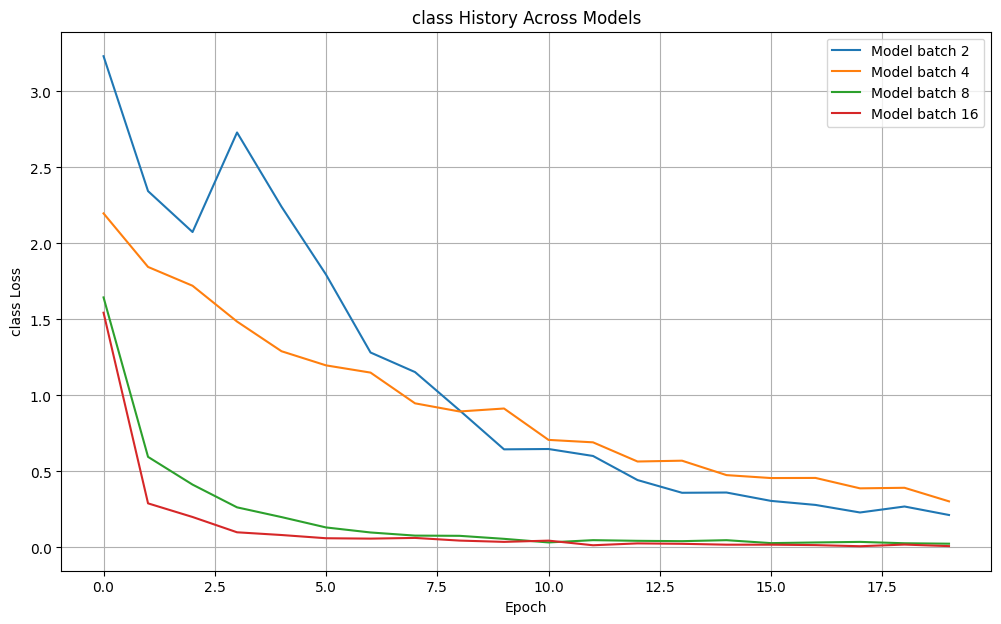

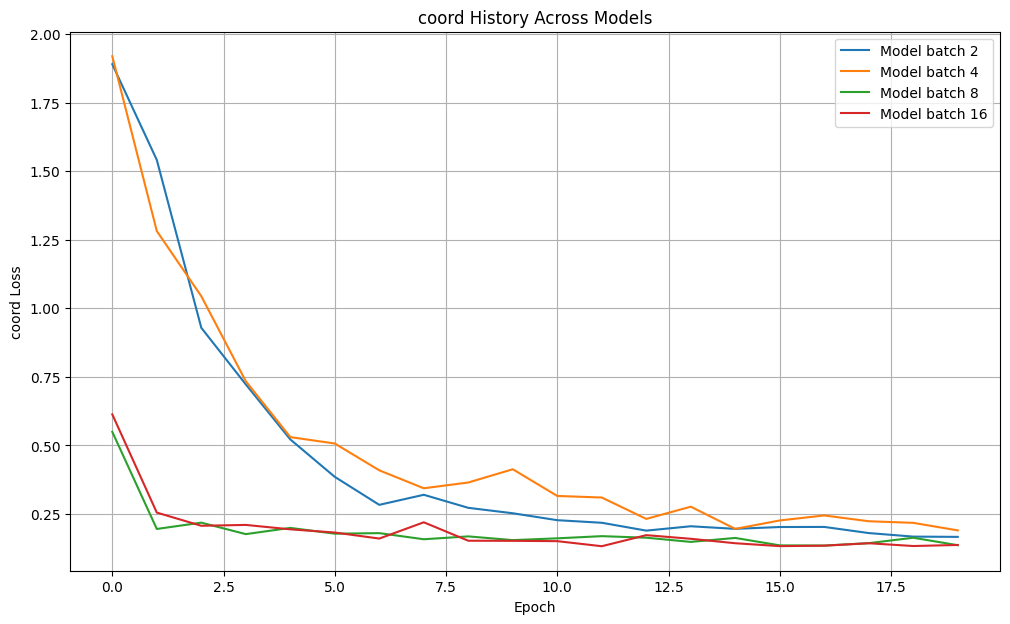

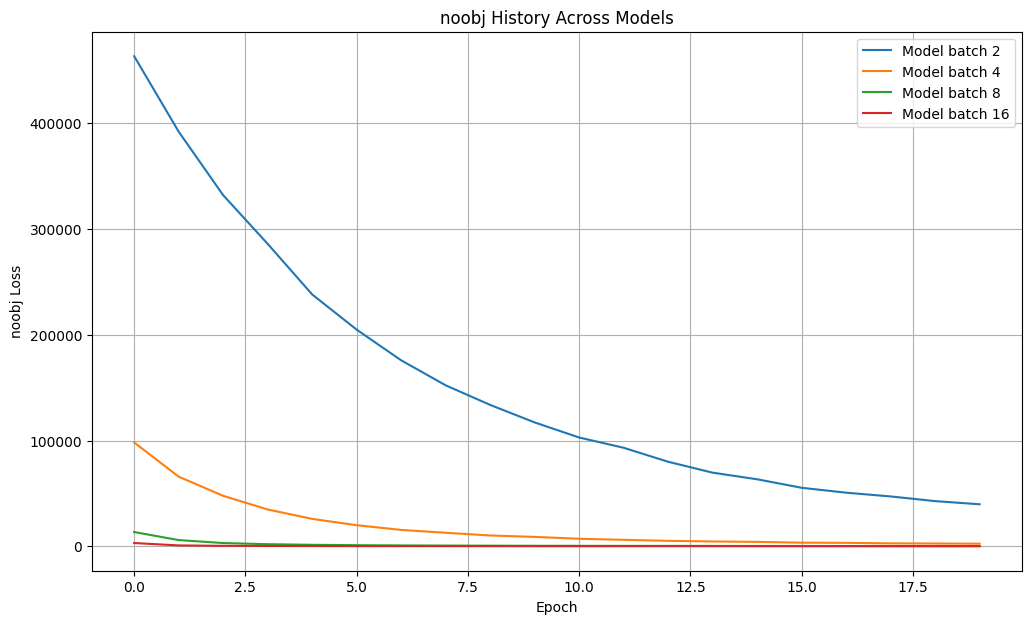

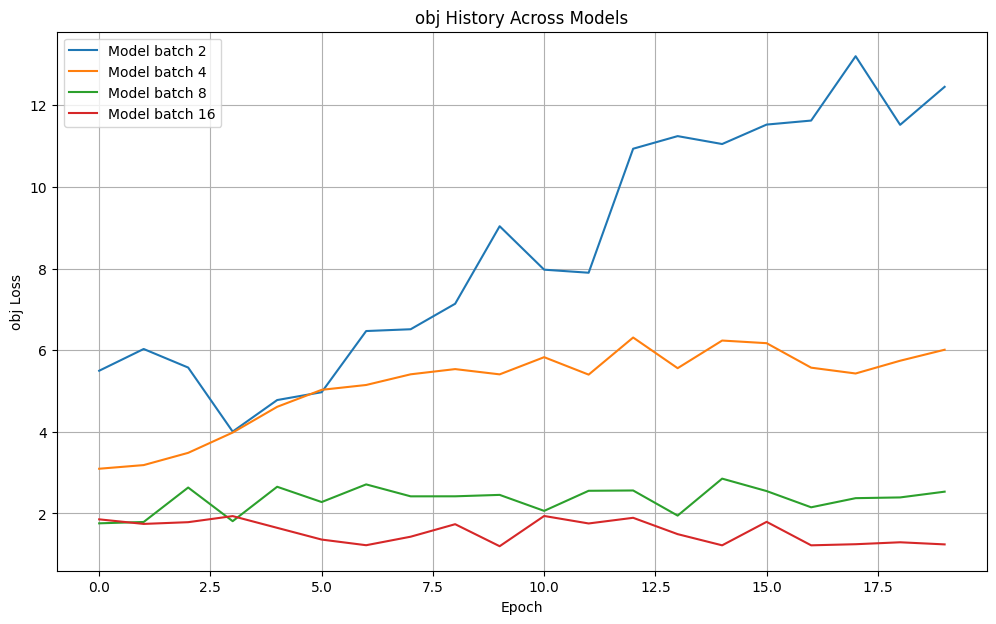

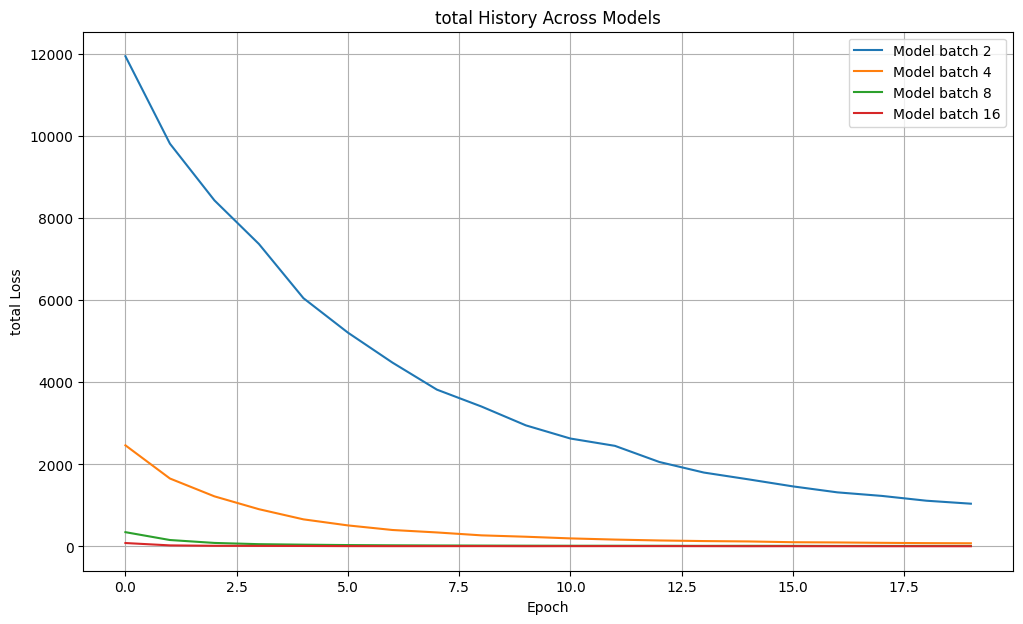

In [ ]:
import matplotlib.pyplot as plt

all_loss_categories = set()
for model in models:
    if isinstance(model.loss_history, dict):
        all_loss_categories.update(model.loss_history.keys())
    else:
        all_loss_categories.add('Total Loss')


if 'Total Loss' not in all_loss_categories and any(not isinstance(m.loss_history, dict) for m in models):
    
    pass

sorted_categories = sorted(list(all_loss_categories))

for category in sorted_categories:
    plt.figure(figsize=(12, 7))
    for i, model in enumerate(models):
        reduction_factor = model.get_reduction_factor()
        if isinstance(model.loss_history, dict):
            if category in model.loss_history:
                plt.plot(model.loss_history[category], label=f'Model reduction factor {reduction_factor}')
        elif category == 'Total Loss': 
            plt.plot(model.loss_history, label=f'Model reduction factor {reduction_factor}')
            
    plt.title(f'{category} History Across Models')
    plt.xlabel('Epoch')
    plt.ylabel(f'{category} Loss')
    plt.legend()
    plt.grid(True)
    plt.show()